# Sentiment & Marketing Attribution 

**Business Question:**  
How do guest review sentiments differ across NYC vs Dubai inventory, which themes drive positive/negative perception, and what marketing actions should OTA take?

| # | Source | Signal | Used For |
|---|--------|--------|----------|
| 1 | Processed hotel dataset with review text | review sentiment + topics | brand/reputation diagnosis |
| 2 | Sentiment engine outputs | market/topic aggregates + rating mismatch | campaign and merchandising actions |

### Pipeline
1. Load processed hotel data
2. Extract review-level rows
3. Score sentiment per review
4. Extract topical themes from review text
5. Aggregate sentiment by market/price/topic
6. Check sentiment vs rating mismatch
7. Produce marketing recommendations

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config.settings import DATA_PROCESSED, FIGURES_DIR
from src.preprocessing.hotels import prepare_funnel_data
import src.analysis.sentiment_engine as se

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "sentiment_marketing").mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")
print("VADER available:", se.HAS_VADER)

✅ Setup complete
VADER available: True


In [2]:
candidates = [
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched_processed.csv",
    DATA_PROCESSED / "booking_funnel" / "hotels_enriched.csv",
    DATA_PROCESSED / "hotels_prepared.parquet",
    DATA_PROCESSED / "hotels_prepared.csv",
    DATA_PROCESSED / "hotels.csv",
]

hotels = None
source_used = None

for p in candidates:
    if p.exists():
        try:
            hotels = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
            source_used = str(p)
            break
        except Exception as e:
            print(f"Failed reading {p.name}: {e}")

if hotels is None:
    raise FileNotFoundError(
        "No processed hotel dataset found for M05.\nChecked:\n" + "\n".join(str(x) for x in candidates)
    )

# Ensure key enrichment exists
required_enriched = {"PRICE_TIER", "RATING_TIER", "VISIBILITY_SCORE", "IS_BOOKABLE"}
if not required_enriched.issubset(hotels.columns):
    hotels = prepare_funnel_data(hotels)

# Ensure review text column exists
if "REVIEW_TEXTS" not in hotels.columns:
    raise ValueError(
        "REVIEW_TEXTS column not found in processed dataset. "
        "M05 requires review text payload in hotels data."
    )

print(f"✅ Loaded hotels from: {source_used}")
print(f"Rows: {len(hotels):,}")
print("Markets:", hotels["MARKET"].value_counts(dropna=False).to_dict() if "MARKET" in hotels.columns else "N/A")
display(hotels.head())

✅ Loaded hotels from: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\booking_funnel\hotels_enriched_processed.csv
Rows: 202
Markets: {'NYC': 106, 'Dubai': 96}


,PLACE_ID,NAME,MARKET,RATING,TOTAL_RATINGS,PRICE_LEVEL,ADDRESS,LAT,LNG,BUSINESS_STATUS,...,PHONE,NUM_PHOTOS,NUM_REVIEWS_FETCHED,AVG_REVIEW_RATING,REVIEW_TEXTS,OPEN_NOW,PRICE_TIER,RATING_TIER,VISIBILITY_SCORE,IS_BOOKABLE
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,4.7,30807,NaN,Dubai - Umm Suqeim Third - Umm Suqeim 3 - Duba...,25.141191,55.185247,OPERATIONAL,...,04 301 7777,10,5,5.0,Staying in a suite at the Burj Al Arab was tru...,NaN,Unknown,Excellent,92.8,True
1,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,4.7,101541,NaN,Crescent Rd - The Palm Jumeirah - Dubai - Unit...,25.130443,55.117150,OPERATIONAL,...,04 426 0000,10,5,4.8,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,NaN,Unknown,Excellent,97.9,True
2,ChIJ_-wTYzdrXz4RrrhErFCw21o,FIVE Palm Jumeirah Hotel,Dubai,4.7,25103,NaN,No. 1 Palm - The Palm Jumeirah - Dubai - Unite...,25.104330,55.148769,OPERATIONAL,...,04 455 9999,10,5,5.0,I had an amazing stay at **FIVE Palm Jumeirah*...,True,Unknown,Excellent,84.4,True
3,ChIJ9c0WNcoUXz4RmIIVjEG9uqo,One&Only The Palm,Dubai,4.7,3103,NaN,"West Crescent, Palm - نخلة جميرا - Jumeirah - ...",25.099485,55.133463,OPERATIONAL,...,04 440 1010,10,5,5.0,One&Only The Palm is the definition of quiet l...,True,Unknown,Excellent,52.4,True
4,ChIJ8-LpJSNCXz4RSYU8D8qlVl4,Bvlgari Resort Dubai,Dubai,4.6,3870,NaN,Jumeirah Bay Island - جميرا باي - جميرا ٢ - دب...,25.210697,55.236428,OPERATIONAL,...,04 777 5555,10,5,5.0,I had an amazing stay here. everything from th...,NaN,Unknown,Excellent,52.8,True


## Extract Review-Level Dataset

In [3]:
reviews = se.extract_reviews(hotels)

print(f"Total extracted reviews: {len(reviews):,}")
print("Markets:", reviews["MARKET"].value_counts(dropna=False).to_dict() if "MARKET" in reviews.columns else "N/A")
display(reviews.head(10))

Total extracted reviews: 1,005
Markets: {'NYC': 530, 'Dubai': 475}


,PLACE_ID,HOTEL_NAME,MARKET,NEIGHBORHOOD,PRICE_TIER,RATING,REVIEW_INDEX,REVIEW_TEXT
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,0,Staying in a suite at the Burj Al Arab was tru...
1,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,1,Burj al Arab is an iconic place for lots of ye...
2,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,2,Our stay at the Burj Al Arab was honestly unfo...
3,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,3,The view from the Skyview Bar is absolutely br...
4,ChIJLc8UZFdqXz4ROODwebhx2rM,Jumeirah Burj Al Arab,Dubai,,Unknown,4.7,4,The Burj Al Arab in Dubai is the definition of...
5,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,,Unknown,4.7,0,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...
6,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,,Unknown,4.7,1,Seriosuly the best Hotel we have ever stayed a...
7,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,,Unknown,4.7,2,This is our 3rd visit over the past 15 years. ...
8,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,,Unknown,4.7,3,Had the absolute best day with my favorite 2 m...
9,ChIJeckJNj4VXz4RxUqAikFalAU,Atlantis - The Palm,Dubai,,Unknown,4.7,4,Atlantis is truly a 5-star experience in every...


In [4]:
qc = {
    "N_REVIEWS": len(reviews),
    "N_HOTELS_WITH_REVIEWS": reviews["PLACE_ID"].nunique() if "PLACE_ID" in reviews.columns else np.nan,
    "AVG_REVIEW_LEN": reviews["REVIEW_TEXT"].astype(str).str.len().mean() if len(reviews) else np.nan,
    "PCT_EMPTY_TEXT": (reviews["REVIEW_TEXT"].astype(str).str.strip().eq("").mean() * 100) if len(reviews) else np.nan,
}
display(pd.DataFrame([qc]).T)

,0
N_REVIEWS,1005.00000
N_HOTELS_WITH_REVIEWS,202.00000
AVG_REVIEW_LEN,782.21194
PCT_EMPTY_TEXT,0.00000


## Sentiment Scoring

In [5]:
reviews_sent = se.analyze_review_sentiment(reviews)

display(reviews_sent[[
    "PLACE_ID", "MARKET", "PRICE_TIER", "RATING",
    "REVIEW_TEXT", "VADER_COMPOUND", "SENTIMENT_LABEL"
]].head(10))

,PLACE_ID,MARKET,PRICE_TIER,RATING,REVIEW_TEXT,VADER_COMPOUND,SENTIMENT_LABEL
0,ChIJLc8UZFdqXz4ROODwebhx2rM,Dubai,Unknown,4.7,Staying in a suite at the Burj Al Arab was tru...,0.9832,Positive
1,ChIJLc8UZFdqXz4ROODwebhx2rM,Dubai,Unknown,4.7,Burj al Arab is an iconic place for lots of ye...,0.9959,Positive
2,ChIJLc8UZFdqXz4ROODwebhx2rM,Dubai,Unknown,4.7,Our stay at the Burj Al Arab was honestly unfo...,0.9884,Positive
3,ChIJLc8UZFdqXz4ROODwebhx2rM,Dubai,Unknown,4.7,The view from the Skyview Bar is absolutely br...,0.9842,Positive
4,ChIJLc8UZFdqXz4ROODwebhx2rM,Dubai,Unknown,4.7,The Burj Al Arab in Dubai is the definition of...,0.9552,Positive
5,ChIJeckJNj4VXz4RxUqAikFalAU,Dubai,Unknown,4.7,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,0.9944,Positive
6,ChIJeckJNj4VXz4RxUqAikFalAU,Dubai,Unknown,4.7,Seriosuly the best Hotel we have ever stayed a...,0.9633,Positive
7,ChIJeckJNj4VXz4RxUqAikFalAU,Dubai,Unknown,4.7,This is our 3rd visit over the past 15 years. ...,0.9722,Positive
8,ChIJeckJNj4VXz4RxUqAikFalAU,Dubai,Unknown,4.7,Had the absolute best day with my favorite 2 m...,0.9642,Positive
9,ChIJeckJNj4VXz4RxUqAikFalAU,Dubai,Unknown,4.7,Atlantis is truly a 5-star experience in every...,0.9847,Positive


,SENTIMENT_LABEL,PCT
0,Positive,88.756219
1,Negative,10.746269
2,Neutral,0.497512


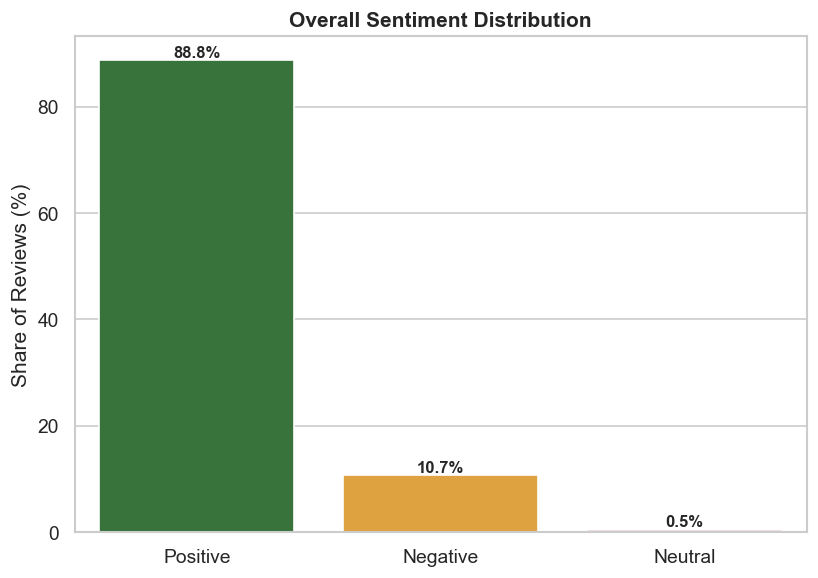

In [6]:
# Sentiment label distribution
sent_dist = (
    reviews_sent["SENTIMENT_LABEL"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("SENTIMENT_LABEL")
    .reset_index(name="PCT")
)
display(sent_dist)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=sent_dist, x="SENTIMENT_LABEL", y="PCT", palette=["#2e7d32", "#f9a825", "#c62828"], ax=ax)
ax.set_title("Overall Sentiment Distribution", fontweight="bold")
ax.set_ylabel("Share of Reviews (%)")
ax.set_xlabel("")
for i, v in enumerate(sent_dist["PCT"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m05_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Topic Extraction from Reviews

In [7]:
reviews_topic = se.extract_sentiment_topics(reviews_sent)

topic_cols = [c for c in reviews_topic.columns if c.startswith("TOPIC_")]
print("Detected topic columns:", topic_cols)
display(reviews_topic[["REVIEW_TEXT", "PRIMARY_TOPIC"] + topic_cols[:5]].head(10))

Detected topic columns: ['TOPIC_LOCATION', 'TOPIC_SERVICE', 'TOPIC_PRICE_VALUE', 'TOPIC_ROOM_QUALITY', 'TOPIC_FOOD_DINING', 'TOPIC_AMENITIES', 'TOPIC_VIEWS_AMBIANCE']


,REVIEW_TEXT,PRIMARY_TOPIC,TOPIC_LOCATION,TOPIC_SERVICE,TOPIC_PRICE_VALUE,TOPIC_ROOM_QUALITY,TOPIC_FOOD_DINING
0,Staying in a suite at the Burj Al Arab was tru...,location,1,1,1,1,0
1,Burj al Arab is an iconic place for lots of ye...,service,0,1,0,1,1
2,Our stay at the Burj Al Arab was honestly unfo...,service,0,1,1,1,1
3,The view from the Skyview Bar is absolutely br...,service,0,1,0,0,1
4,The Burj Al Arab in Dubai is the definition of...,service,0,1,0,1,0
5,🌟🌟🌟🌟🌟\nAtlantis The Palm meets the King of Lov...,service,0,1,0,0,0
6,Seriosuly the best Hotel we have ever stayed a...,location,1,0,0,1,0
7,This is our 3rd visit over the past 15 years. ...,service,0,1,1,0,0
8,Had the absolute best day with my favorite 2 m...,amenities,0,0,0,0,0
9,Atlantis is truly a 5-star experience in every...,service,0,1,0,1,1


,PRIMARY_TOPIC,PCT
0,location,48.159204
1,service,41.194030
2,room_quality,5.373134
3,price_value,2.288557
4,amenities,1.592040
5,general,0.796020
6,food_dining,0.597015


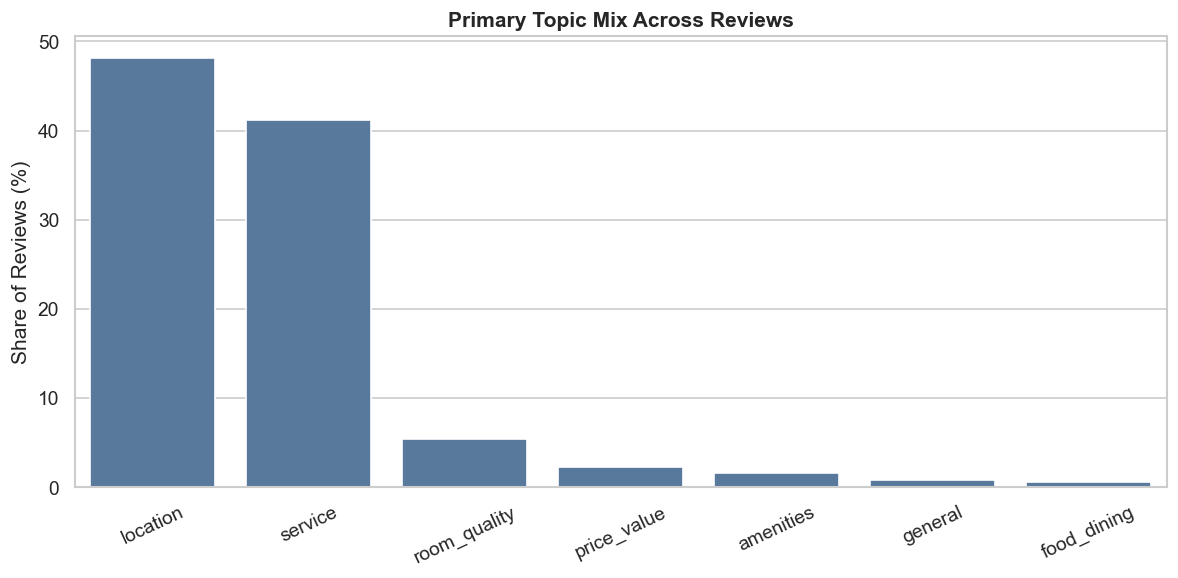

In [8]:
topic_dist = (
    reviews_topic["PRIMARY_TOPIC"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("PRIMARY_TOPIC")
    .reset_index(name="PCT")
    .sort_values("PCT", ascending=False)
)

display(topic_dist)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=topic_dist, x="PRIMARY_TOPIC", y="PCT", color="#4e79a7", ax=ax)
ax.set_title("Primary Topic Mix Across Reviews", fontweight="bold")
ax.set_ylabel("Share of Reviews (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m05_topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Aggregated Sentiment by Market / Price Tier / Topic

In [9]:
sent_market = se.aggregate_sentiment_by_group(reviews_topic, group_col="MARKET")
display(sent_market)

,MARKET,REVIEW_COUNT,AVG_COMPOUND,MEDIAN_COMPOUND,STD_COMPOUND,PCT_POSITIVE,PCT_NEGATIVE,PCT_NEUTRAL
0,Dubai,475,0.804,0.987,0.501,91.368,8.211,0.421
1,NYC,530,0.706,0.971,0.588,86.415,13.019,0.566


In [10]:
sent_price = se.aggregate_sentiment_by_group(reviews_topic, group_col="PRICE_TIER")
display(sent_price)

,PRICE_TIER,REVIEW_COUNT,AVG_COMPOUND,MEDIAN_COMPOUND,STD_COMPOUND,PCT_POSITIVE,PCT_NEGATIVE,PCT_NEUTRAL
1,Unknown,975,0.755,0.981,0.549,88.923,10.564,0.513
0,Luxury,10,0.654,0.982,0.687,80.000,20.000,0.000
2,Upscale,20,0.653,0.932,0.577,85.000,15.000,0.000


In [11]:
sent_topic = se.aggregate_sentiment_by_group(reviews_topic, group_col="PRIMARY_TOPIC")
display(sent_topic.head(15))

,PRIMARY_TOPIC,REVIEW_COUNT,AVG_COMPOUND,MEDIAN_COMPOUND,STD_COMPOUND,PCT_POSITIVE,PCT_NEGATIVE,PCT_NEUTRAL
6,service,414,0.798,0.986,0.526,90.580,8.937,0.483
3,location,484,0.793,0.980,0.487,91.116,8.678,0.207
0,amenities,16,0.790,0.910,0.285,93.750,6.250,0.000
2,general,8,0.560,0.458,0.226,100.000,0.000,0.000
1,food_dining,6,0.469,0.685,0.736,83.333,16.667,0.000
4,price_value,23,0.410,0.953,0.830,69.565,30.435,0.000
5,room_quality,54,0.238,0.745,0.833,59.259,37.037,3.704


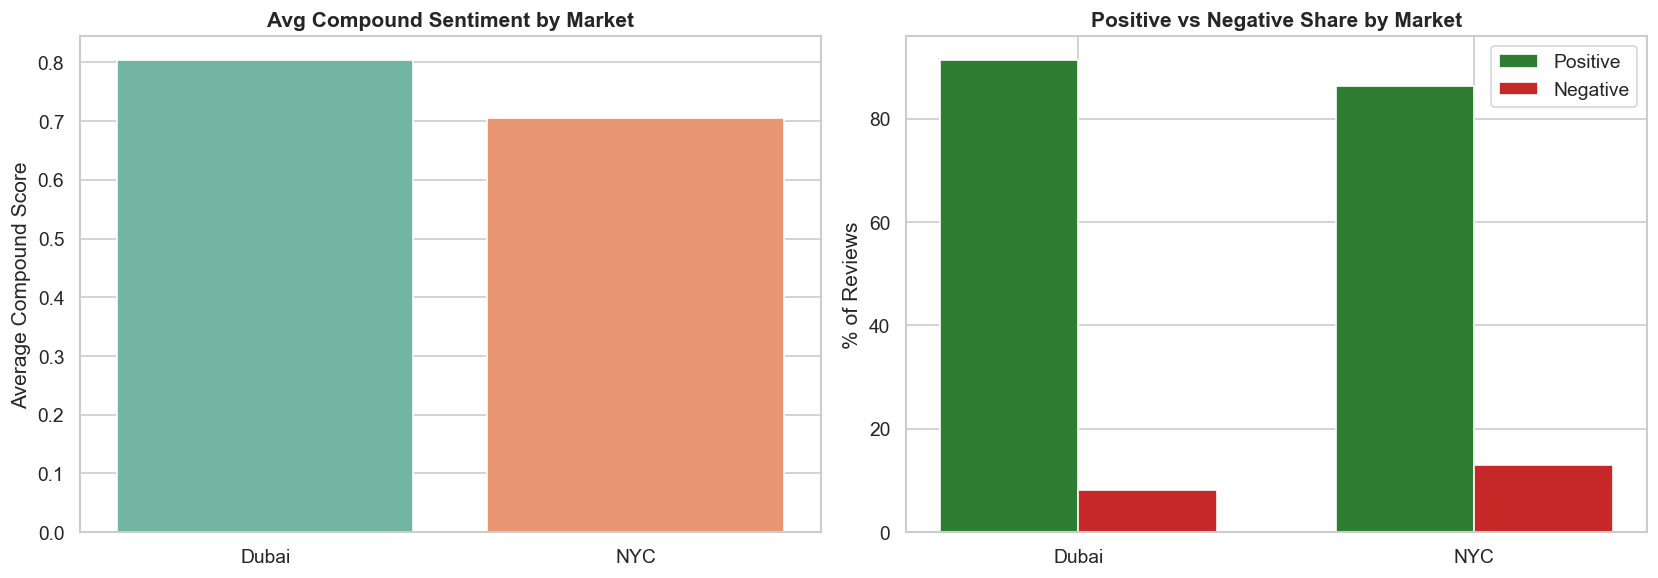

In [12]:
# Market comparison chart
if not sent_market.empty:
    plot_m = sent_market.copy()
    plot_m["MARKET"] = plot_m["MARKET"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=plot_m, x="MARKET", y="AVG_COMPOUND", palette="Set2", ax=axes[0])
    axes[0].set_title("Avg Compound Sentiment by Market", fontweight="bold")
    axes[0].set_ylabel("Average Compound Score")
    axes[0].set_xlabel("")

    x = np.arange(len(plot_m))
    width = 0.35
    axes[1].bar(x - width/2, plot_m["PCT_POSITIVE"], width, label="Positive", color="#2e7d32")
    axes[1].bar(x + width/2, plot_m["PCT_NEGATIVE"], width, label="Negative", color="#c62828")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(plot_m["MARKET"])
    axes[1].set_title("Positive vs Negative Share by Market", fontweight="bold")
    axes[1].set_ylabel("% of Reviews")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m05_market_sentiment_compare.png", dpi=150, bbox_inches="tight")
    plt.show()


## Sentiment vs Star Rating Alignment

In [13]:
# Correlation/mismatch analysis
hotel_sent = se.sentiment_rating_correlation(reviews_topic)
display(hotel_sent.head(15))

mismatch_summary = hotel_sent["MISMATCH"].value_counts().rename_axis("MISMATCH").reset_index(name="HOTEL_COUNT")
display(mismatch_summary)

,PLACE_ID,HOTEL_NAME,MARKET,GOOGLE_RATING,AVG_SENTIMENT,REVIEW_COUNT,MISMATCH
0,ChIJ-8HrdxtawokREfw5AkGs_Os,Conrad New York Downtown,NYC,4.6,0.96650,5,Aligned
1,ChIJ-QLMbNNrXz4RrgsSJK45ae4,NH Collection Dubai The Palm,Dubai,4.8,0.99526,5,Aligned
2,ChIJ-Zgs_xlnwokRpvbg-anYgYQ,Hilton Garden Inn Queens/JFK Airport,NYC,3.6,-0.15800,5,Aligned
3,ChIJ-cLamD1awokRhIfng6G7DqA,Fairfield by Marriott Inn & Suites New York Ma...,NYC,3.9,0.87356,5,Aligned
4,ChIJ-cpyzABDXz4Rr45m1nUOGgk,"LEVA Hotel , Mazaya Centre",Dubai,4.5,0.98330,5,Aligned
5,ChIJ03EE5oNZwokRVyo_F06puDQ,Hotel Indigo Lower East Side New York by IHG,NYC,3.9,0.97208,5,Aligned
6,ChIJ0fci9hNawokRJVR9hdTAt80,DoubleTree by Hilton New York Downtown,NYC,3.6,0.35760,5,Aligned
7,ChIJ15MMyYBZwokRRDnCWcAzD8s,31 Street Broadway Hotel,NYC,2.6,-0.16614,5,Aligned
8,ChIJ1YUKoCBawokR5wfkM635e6o,Walker Hotel Tribeca,NYC,4.1,0.97560,5,Aligned
9,ChIJ2313uydawokRsS853z2RTXc,Hotel 50 Bowery - JDV by Hyatt,NYC,4.5,0.97804,5,Aligned


,MISMATCH,HOTEL_COUNT
0,Aligned,192
1,LowRating_PosSent,7
2,HighRating_NegSent,3


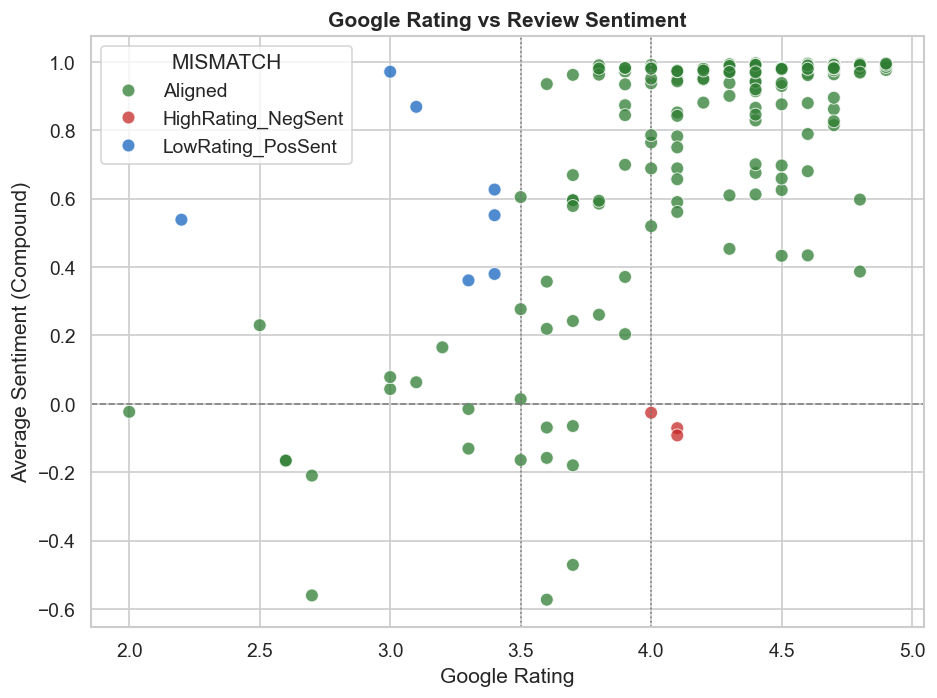

In [14]:
if not hotel_sent.empty:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=hotel_sent,
        x="GOOGLE_RATING",
        y="AVG_SENTIMENT",
        hue="MISMATCH",
        palette={"Aligned":"#2e7d32", "HighRating_NegSent":"#c62828", "LowRating_PosSent":"#1565c0"},
        alpha=0.75,
        s=60,
        ax=ax,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(4.0, color="gray", linestyle=":", linewidth=1)
    ax.axvline(3.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title("Google Rating vs Review Sentiment", fontweight="bold")
    ax.set_xlabel("Google Rating")
    ax.set_ylabel("Average Sentiment (Compound)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m05_rating_sentiment_mismatch.png", dpi=150, bbox_inches="tight")
    plt.show()

## Marketing Attribution View (Topic × Sentiment)

In [15]:
# Topic-level positivity/negativity driver table
driver = (
    reviews_topic.groupby("PRIMARY_TOPIC")
    .agg(
        REVIEW_COUNT=("REVIEW_TEXT", "count"),
        AVG_COMPOUND=("VADER_COMPOUND", "mean"),
        PCT_POSITIVE=("SENTIMENT_LABEL", lambda x: (x == "Positive").mean() * 100),
        PCT_NEGATIVE=("SENTIMENT_LABEL", lambda x: (x == "Negative").mean() * 100),
    )
    .reset_index()
)

driver["NET_SENTIMENT"] = driver["PCT_POSITIVE"] - driver["PCT_NEGATIVE"]
driver = driver.sort_values(["NET_SENTIMENT", "REVIEW_COUNT"], ascending=[False, False])

display(driver)

,PRIMARY_TOPIC,REVIEW_COUNT,AVG_COMPOUND,PCT_POSITIVE,PCT_NEGATIVE,NET_SENTIMENT
2,general,8,0.560150,100.000000,0.000000,100.000000
0,amenities,16,0.790388,93.750000,6.250000,87.500000
3,location,484,0.792641,91.115702,8.677686,82.438017
6,service,414,0.797919,90.579710,8.937198,81.642512
1,food_dining,6,0.468800,83.333333,16.666667,66.666667
4,price_value,23,0.409709,69.565217,30.434783,39.130435
5,room_quality,54,0.238220,59.259259,37.037037,22.222222


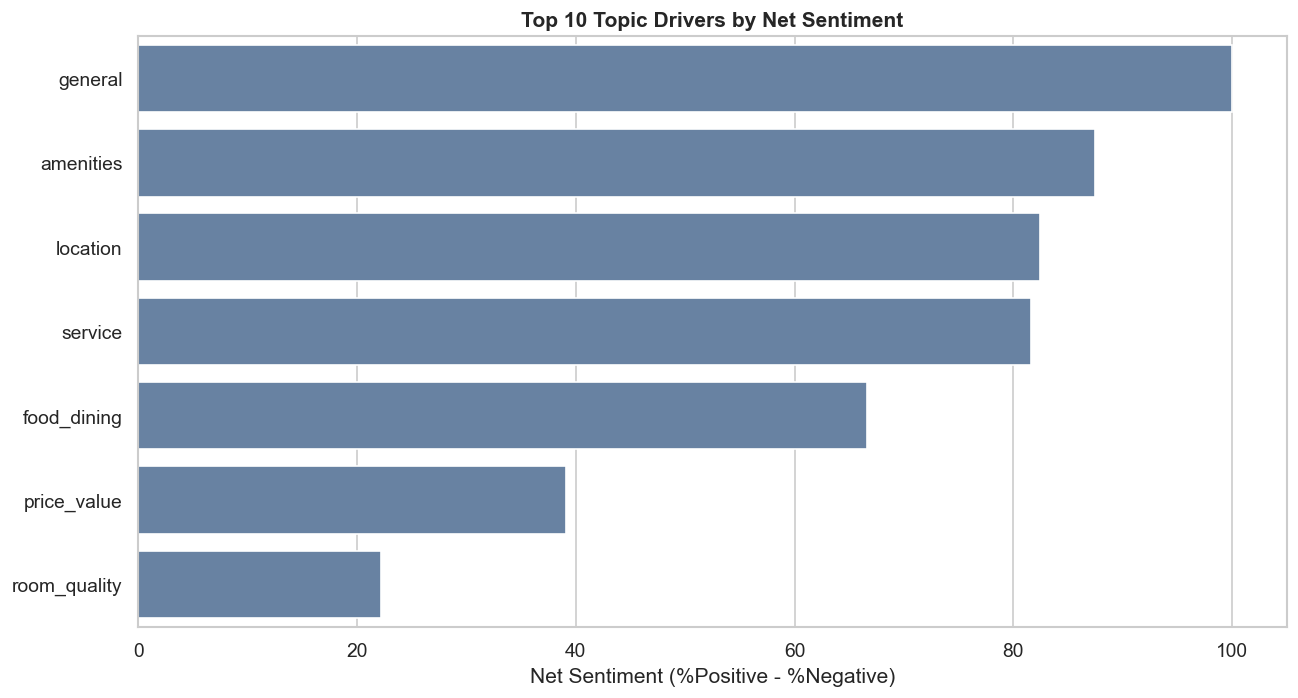

In [16]:
top_n = 10
dplot = driver.head(top_n).copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=dplot, x="NET_SENTIMENT", y="PRIMARY_TOPIC", color="#5e81ac", ax=ax)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Top {top_n} Topic Drivers by Net Sentiment", fontweight="bold")
ax.set_xlabel("Net Sentiment (%Positive - %Negative)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m05_topic_net_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

## Action Framework — What Marketing Should Do

In [17]:
actions = []

# 1) Market-level insight
if not sent_market.empty and "MARKET" in sent_market.columns:
    top_market = sent_market.sort_values("AVG_COMPOUND", ascending=False).iloc[0]
    low_market = sent_market.sort_values("AVG_COMPOUND", ascending=True).iloc[0]
    actions.append({
        "PRIORITY": "High",
        "AREA": "Market Messaging",
        "INSIGHT": f"{top_market['MARKET']} has stronger sentiment than {low_market['MARKET']}",
        "ACTION": f"Use {top_market['MARKET']} UGC/testimonials for performance creatives; fix trust frictions in {low_market['MARKET']}"
    })

# 2) Topic-level positives
if not driver.empty:
    best_topic = driver.iloc[0]
    worst_topic = driver.sort_values("NET_SENTIMENT", ascending=True).iloc[0]
    actions.append({
        "PRIORITY": "High",
        "AREA": "Content Strategy",
        "INSIGHT": f"Best perception topic: {best_topic['PRIMARY_TOPIC']}; weakest: {worst_topic['PRIMARY_TOPIC']}",
        "ACTION": f"Lead ad copy with {best_topic['PRIMARY_TOPIC']} strengths; launch remediation playbook for {worst_topic['PRIMARY_TOPIC']}"
    })

# 3) Rating mismatch
if not mismatch_summary.empty:
    high_neg = int(mismatch_summary.loc[mismatch_summary["MISMATCH"]=="HighRating_NegSent", "HOTEL_COUNT"].sum()) if "HighRating_NegSent" in mismatch_summary["MISMATCH"].values else 0
    actions.append({
        "PRIORITY": "Medium",
        "AREA": "Reputation Risk",
        "INSIGHT": f"{high_neg} hotels show high rating but negative sentiment mismatch",
        "ACTION": "Audit listing content and recent complaints; downgrade placement until review quality recovers"
    })

actions_df = pd.DataFrame(actions)
display(actions_df)

,PRIORITY,AREA,INSIGHT,ACTION
0,High,Market Messaging,Dubai has stronger sentiment than NYC,Use Dubai UGC/testimonials for performance cre...
1,High,Content Strategy,Best perception topic: general; weakest: room_...,Lead ad copy with general strengths; launch re...
2,Medium,Reputation Risk,3 hotels show high rating but negative sentime...,Audit listing content and recent complaints; d...


In [18]:
# Cell 20 (Code) — save outputs
out = DATA_PROCESSED / "sentiment_marketing"
out.mkdir(parents=True, exist_ok=True)

reviews.to_csv(out / "reviews_extracted.csv", index=False)
reviews_sent.to_csv(out / "reviews_sentiment_scored.csv", index=False)
reviews_topic.to_csv(out / "reviews_with_topics.csv", index=False)
sent_market.to_csv(out / "sentiment_by_market.csv", index=False)
sent_price.to_csv(out / "sentiment_by_price_tier.csv", index=False)
sent_topic.to_csv(out / "sentiment_by_primary_topic.csv", index=False)
hotel_sent.to_csv(out / "rating_sentiment_correlation.csv", index=False)
driver.to_csv(out / "topic_sentiment_drivers.csv", index=False)
actions_df.to_csv(out / "marketing_actions.csv", index=False)

print(f"✅ Outputs saved to: {out}")
print(f"✅ Figures saved to: {FIGURES_DIR}")

✅ Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\sentiment_marketing
✅ Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures



1. Review-level sentiment scores (positive/neutral/negative)
2. Topic-level sentiment drivers (location, service, price-value, room quality, etc.)
3. Market-level and price-tier sentiment comparisons
4. Rating-vs-sentiment mismatch detection for reputation risk
5. Prioritized marketing action recommendations

### Decision Usage
- **Acquisition:** align creatives to high-sentiment topics
- **Conversion:** improve weak sentiment topics on landing/listing UX
- **Trust:** mitigate high-rating/negative-sentiment mismatch hotels
- **Retention:** amplify strongest UGC themes by segment and market